In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

In [21]:
df = pd.read_csv("../files/early_diabetes_data_cleaned.csv")

target = df['class']
features = df.drop('class', axis = 1).copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)


In [13]:
log_reg = LogisticRegression(l1_ratio = 1, solver = 'liblinear', random_state=42)
param_grid = {
    'C' : [0.001, 0.01, 0.1, 1, 10, 100]
}

gcv = GridSearchCV(log_reg, param_grid = param_grid, cv = 5, n_jobs = -1)
gcv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter

In [50]:
opt_log_reg = gcv.best_estimator_
coef = opt_log_reg.coef_

coef_dict = {
    'coef' : np.exp(coef.ravel()),
    'features' : features.columns,
}

coef_df = (pd.DataFrame(coef_dict)
           .sort_values(by=['coef'], ascending = False))


In [37]:
# Predictions
y_pred_proba = opt_log_reg.predict_proba(X_test)
y_pred = opt_log_reg.predict(X_test)

# Metric : Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Metric : AUC score
roc_auc = roc_auc_score(y_test, y_pred)

# Rates
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[28  5]
 [ 2 69]]


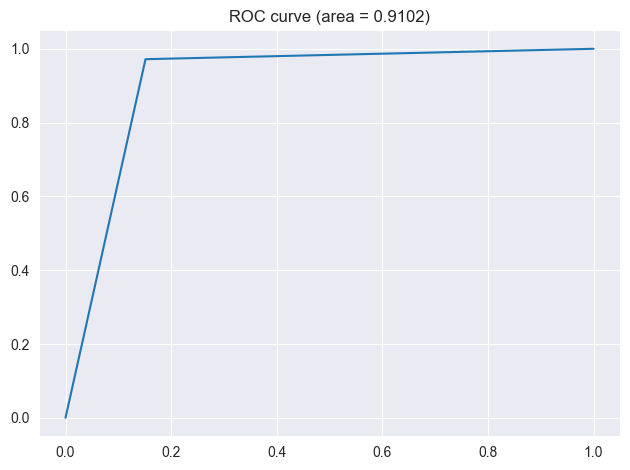

In [38]:
fig = plt.subplot()

fig.plot(fpr,tpr)
plt.title(f"ROC curve (area = {round(roc_auc, 4)})")
plt.tight_layout()
plt.show()

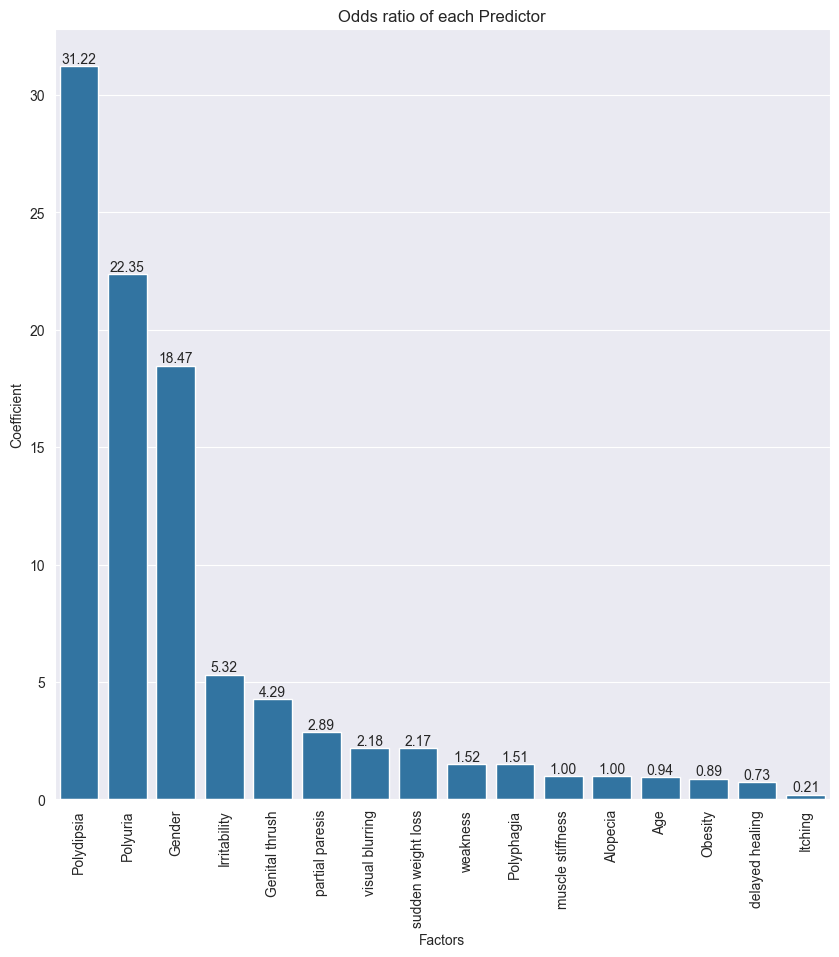

In [52]:
fig, ax = plt.subplots(figsize = (10,10))

sns.barplot(data=coef_df, x = 'features', y = 'coef',ax = ax)

ax.tick_params(axis='x', rotation=90)
ax.set_ylabel('Coefficient')
ax.set_xlabel('Factors')
ax.set_title('Odds ratio of each Predictor')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')


In [48]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(log_reg, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)

selected_features = X_train.columns[sfs.get_support()]

In [49]:
selected_features

Index(['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'Alopecia'], dtype='str')